In [39]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms.optimizers import ADAM
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.algorithms import NeuralNetworkClassifier
from qiskit_machine_learning.utils.loss_functions import CrossEntropyLoss

import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd

In [40]:
# Function to Build the Quantum Circuit
def BuildQC(N,x,theta):

    # -----------------------
    # Feature Map
    # -----------------------
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    for i in range(N-1):
        qc.cx(i, i+1)
        qc.rz(x[i] * x[i+1], i+1)
        qc.cx(i, i+1)
    qc.barrier()
    # -----------------------
    # Variational Model
    # -----------------------
    for i in range(N):
        qc.ry(theta[i], i)
    qc.barrier()
    for i in range(N-1):
        qc.cx(i, i+1)
    qc.barrier()
    for i in range(N):
        qc.ry(theta[i+N], i)

    return qc

In [ ]:
# Read and scale data from Iris Dataset
df=pd.read_csv("Iris/iris.data",header=None, 
               names = ["S-length", "S-width", "P-length","P-width","label"])


# Filter for binary classification
df = df[df["label"].isin(["Iris-setosa", "Iris-versicolor"])]

feature_col = ["S-length", "S-width", "P-length","P-width"]
label_col   = "label"

x = df[feature_col].values
y = LabelEncoder().fit_transform(df["label"].values)
#y = 2*y - 1  # conversion {0,1} → {-1,+1}

# Conversion features in [-1,1]
scaler   = MinMaxScaler(feature_range=(-1, 1))        
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

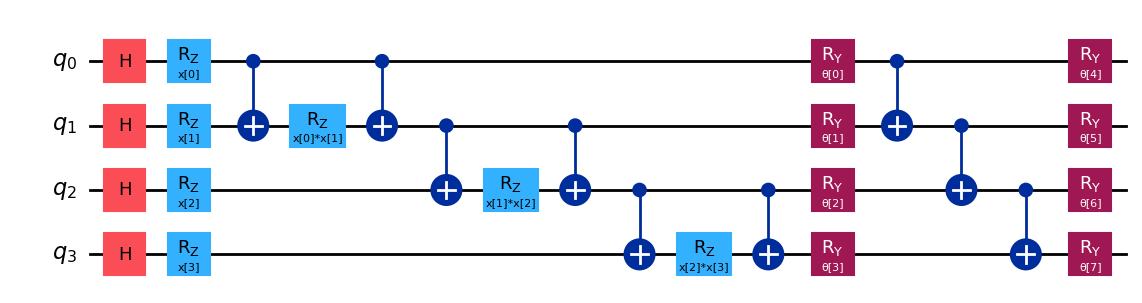

In [42]:
N = len(feature_col)
x     = ParameterVector('x', N)       # input parameter N
theta = ParameterVector('θ', 2*N)     # variational parameter 2N

# Showing the Circuit
qc = BuildQC(N,x,theta)
qc.draw("mpl", style="iqp",plot_barriers=False)

In [43]:
sampler = StatevectorSampler()

qnn = SamplerQNN(
    circuit=qc,
    input_params=list(x),       # ← input parameters
    weight_params=list(theta),  # ← optimization parameter: 2N
    sampler=sampler
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


In [45]:
loss_history = []
# function to  get the loss
def adam_with_tracking(fun, x0, jac=None, **kwargs):
    optimizer = ADAM(maxiter=100, lr=0.1, beta_1=0.9, beta_2=0.99, tol=1e-8)

    def tracked_jac(weights):
        loss = fun(weights)                  
        loss_history.append(float(loss))
        print(f"  iter {len(loss_history):>3d} | loss: {loss:.4f}")
        return jac(weights)                  

    return optimizer.minimize(fun=fun, x0=x0, jac=tracked_jac)

classifier = NeuralNetworkClassifier(
    neural_network=qnn,
    optimizer=adam_with_tracking,
    #loss=SquaredLoss(),
)

print("Training in corso...")
classifier.fit(x_train, y_train)

print(f"\nAccuratezza train : {classifier.score(x_train, y_train):.2%}")  
print(f"Accuratezza test  : {classifier.score(x_test,  y_test):.2%}")    


Training in corso...
  iter   1 | loss: 114.9531
  iter   2 | loss: 104.7048
  iter   3 | loss: 94.0394
  iter   4 | loss: 84.4047
  iter   5 | loss: 76.1264
  iter   6 | loss: 69.7470
  iter   7 | loss: 64.8394
  iter   8 | loss: 62.0103


KeyboardInterrupt: 

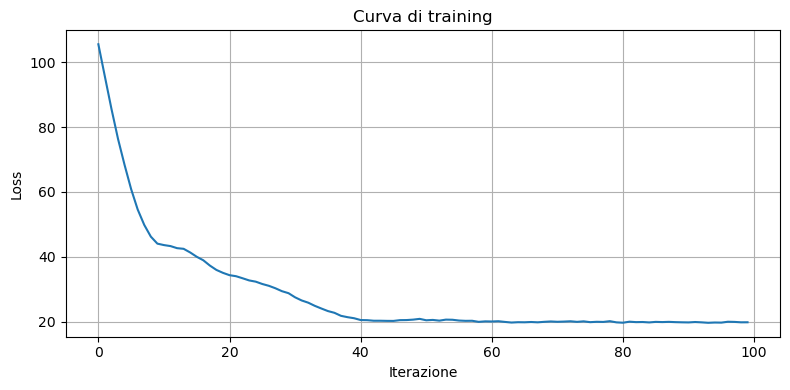

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Iterazione")
plt.ylabel("Loss")
plt.title("Curva di training")
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
print(loss_history)

[19.84404296875]
